### 📚 Lab Task 2: Cleaning Up the Mess

You’ll be working with a dataset of real student grades — 7 assignments and a final exam — but things aren’t as clean as they should be. Some values are missing, some are way off, and it’s your job to fix it.

You’ll explore the data, figure out what went wrong, and try different strategies to clean it up.

Get ready to:
- Spot broken data
- Try out different fixes
- Compare models
- Justify your decisions

### Dataset Introduction

The dataset comes from real student grades in a course at SFU. Students completed **7 assignments**, and we also have their **final exam grade**.

It’s your job to explore the dataset and clean it up.

---

> 💡 **Note**: Students could receive bonus marks for some assignments:
> - **A2**: up to **15** points
> - **A4**: up to **5** points
> - **A6**: up to **10** points  
> Keep this in mind when you're evaluating high or unusual scores — they might not be errors!


**Attention:** The bonus values are in **points** not **percentages**!!!
---

### ✅ What You Need to Do

-  **Explore the dataset**
  - Look at basic stats, column names, and what the data looks like
  - Identify anything that stands out right away

-  **Check the correlations**
  - Use a correlation matrix to find relationships between assignments and the final exam
  - Do any assignments seem strongly related to final exam performance?

-  **If you could only use two assignment grades to predict the final exam**, which ones would you choose — and why?

-  **Check for missing values**
  - Which columns have them?
  - How many are missing?

-  **Handle the missing values**
  - Try out different imputation strategies (mean, median, remove, etc.)
  - Which one gives you the best results? Why do you think that is?
  - Exploration idea: search and see what are the ways of evaluating your results. How can you make sure that a strategy for handling the missing values works better than the other?

-  **Check for outliers**
  - Identify values that seem unrealistic or suspicious
  - Decide whether to keep, modify, or remove them — and explain your reasoning
  - Compare the results

---

For each step, be ready to explain your decisions. There isn’t always one "right" answer — we’re more interested in your reasoning!

> 💡 **Note**: If handling missing values and outliers for **all 7 assignments** feels overwhelming, it’s totally fine to **focus on just the two columns you think are most important**.  
> Just make sure your reasoning for choosing them is solid and clearly explained.


In [ ]:
%pip install pandas -q
import pandas as pd

df = pd.read_csv("/Users/jana/Documents/Summer 2026/IAT461/lab02-EDA-main/grades_crpt.csv")

ModuleNotFoundError: No module named 'pandas'

In [ ]:
df.head()

,A1,A2,A3,A4,A5,A6,A7,Final_Exam,user_id
0,NaN,NaN,30.0,75.0,90.0,65.0,50.6,68.8,U001
1,100.0,NaN,NaN,92.5,100.0,100.0,84.4,50.3,U002
2,75.0,69.6,NaN,86.2,100.0,NaN,NaN,67.8,U003
3,25.0,78.6,40.0,0.0,50.0,30.7,0.0,0.0,U004
4,0.0,NaN,0.0,0.0,NaN,NaN,NaN,0.0,U005


In [ ]:
df.describe()

,A1,A2,A3,A4,A5,A6,A7,Final_Exam
count,57.000000,61.000000,62.000000,77.000000,61.000000,67.000000,76.000000,86.000000
mean,83.671930,81.096721,68.174194,82.332468,89.645902,74.437313,78.130263,55.509302
std,34.286481,28.556721,42.343621,39.101984,25.510505,31.176535,26.412058,18.176777
min,-4.500000,-30.600000,-70.100000,-21.600000,7.700000,-17.000000,0.000000,0.000000
25%,75.800000,64.300000,50.000000,72.000000,87.000000,60.000000,70.300000,45.850000
50%,87.500000,91.100000,80.000000,87.500000,95.000000,80.000000,80.000000,56.050000
75%,95.800000,100.000000,93.250000,95.000000,100.000000,92.500000,87.500000,67.725000
max,174.600000,148.900000,152.200000,188.200000,173.900000,183.600000,150.600000,97.500000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   A1          57 non-null     float64
 1   A2          61 non-null     float64
 2   A3          62 non-null     float64
 3   A4          77 non-null     float64
 4   A5          61 non-null     float64
 5   A6          67 non-null     float64
 6   A7          76 non-null     float64
 7   Final_Exam  86 non-null     float64
 8   user_id     86 non-null     object 
dtypes: float64(8), object(1)
memory usage: 6.2+ KB


In [ ]:
# so based on this, we can see what stand out right away. 
# There are so many missing values
# A1 missing 29 out of 86
# A2 missing 25 
# A3 missing 24 
# A4 missing 9 
# A5 missing 25 
# A6 missing 19 
# A7 missing 10

# Negative min in A1,2,3,4, and 7
# All of max is bigger than 100 which is not good

              A1    A2    A3    A4    A5    A6    A7  Final_Exam
A1          1.00 -0.14  0.36  0.30  0.24  0.23 -0.02        0.21
A2         -0.14  1.00  0.21 -0.03  0.01  0.36  0.03        0.28
A3          0.36  0.21  1.00  0.19  0.19 -0.03  0.15        0.28
A4          0.30 -0.03  0.19  1.00  0.04  0.15  0.22        0.40
A5          0.24  0.01  0.19  0.04  1.00  0.24  0.03        0.02
A6          0.23  0.36 -0.03  0.15  0.24  1.00  0.15        0.25
A7         -0.02  0.03  0.15  0.22  0.03  0.15  1.00        0.38
Final_Exam  0.21  0.28  0.28  0.40  0.02  0.25  0.38        1.00


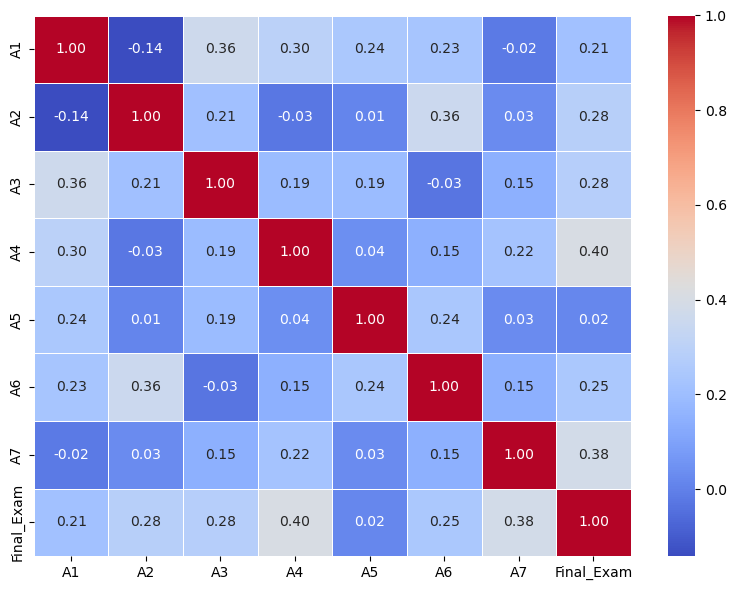

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'Final_Exam']
corr_matrix = df[numeric_cols].corr()
print(corr_matrix.round(2))

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# so here we see A4 and A7 are 2 strongest correlation 
# so i will choose these two cause highest correlation meaning student who do good in these two tended to do well on the final

In [ ]:
print(df.isnull().sum())
print("\nPercentage missing:")
print((df.isnull().sum() / len(df) * 100).round(2))

A1            29
A2            25
A3            24
A4             9
A5            25
A6            19
A7            10
Final_Exam     0
user_id        0
dtype: int64

Percentage missing:
A1            33.72
A2            29.07
A3            27.91
A4            10.47
A5            29.07
A6            22.09
A7            11.63
Final_Exam     0.00
user_id        0.00
dtype: float64


In [ ]:
# So based on this, A1 is the worst as it has 29 missing data which means about 34 % of studets
# however since we decided to focus on A4 and A7, I dont think we need to worry to much as they have the least 
# missing data which makes them better choice to work with


In [ ]:
# Option 1 Remove rows with missing values
# make a copy of dataset
df_option1 = df.dropna(subset=['A4', 'A7'])

# Print the orignal size
print(f"Original size: {len(df)}")

# See after removing the missing, how many row left
print(f"After removing missing: {len(df_option1)}")

# Print total of rows that are removed
print(f"Rows removed: {len(df) - len(df_option1)}")

Original size: 86
After removing missing: 70
Rows removed: 16


In [ ]:
# Option 2 Replace with Mean
# make a copy of dataset
df_option2 = df.copy()

# Fill missing A4 values with the mean of A4
df_option2['A4'] = df_option2['A4'].fillna(df_option2['A4'].mean())

# Fill missing A7 values with the mean of A7
df_option2['A7'] = df_option2['A7'].fillna(df_option2['A7'].mean())

# Confirm no missing values remain in A4 and A7
print(df_option2[['A4', 'A7']].isnull().sum())

A4    0
A7    0
dtype: int64


In [ ]:
# Option 3 Replace with Median
# make a copy of dataset
df_option3 = df.copy()

# Fill missing A4 values with the median of A4
df_option3['A4'] = df_option3['A4'].fillna(df_option3['A4'].median())

# Fill missing A7 values with the median of A7
df_option3['A7'] = df_option3['A7'].fillna(df_option3['A7'].median())

# Confirm no missing values remain in A4 and A7
print(df_option3[['A4', 'A7']].isnull().sum())

A4    0
A7    0
dtype: int64


In [ ]:
# First, print stats for Option 1 to see how distribution changed
print("Option 1 - Remove:")
print(df_option1[['A4', 'A7']].describe().round(2))

# Print stats for Option 2 to compare with Option 1
print("\nOption 2 - Mean:")
print(df_option2[['A4', 'A7']].describe().round(2))

# Print stats for Option 3 to compare with Options 1 and 2
print("\nOption 3 - Median:")
print(df_option3[['A4', 'A7']].describe().round(2))

Option 1 - Remove:
           A4      A7
count   70.00   70.00
mean    81.71   76.03
std     37.69   24.73
min    -21.60    0.00
25%     69.60   69.70
50%     87.50   78.80
75%     95.52   87.02
max    188.20  146.40

Option 2 - Mean:
           A4      A7
count   86.00   86.00
mean    82.33   78.13
std     36.97   24.81
min    -21.60    0.00
25%     75.68   72.50
50%     85.60   78.47
75%     95.00   87.02
max    188.20  150.60

Option 3 - Median:
           A4      A7
count   86.00   86.00
mean    82.87   78.35
std     37.01   24.82
min    -21.60    0.00
25%     75.68   72.50
50%     87.50   80.00
75%     95.00   87.02
max    188.20  150.60


In [ ]:
# so looking at this I can see that option 1 lost 16 rows which is not good cause this is data about real students.
# the mean and std changed slightly well because the dataset lost real data points. 
# Option 2 is good in keeping all 86 rows which is good. The mean of A4 and A7 are close to option 1, it could mean that the distribution is well preserved.
# However, mean is sensitive to outliers since we still have extreme values like -21.6 and 188.2 in our data, the mean is kinda pulled in their direction ->less reliable fill value
# Option 3 also reserves 86 data points. Mean and std are almost identical to option 2, so distribution is also well preserved. 
# Look at the median of A4 and A7, these are more robust to outliers than the mean. Seems like extreme values like -21.6 and 188.2 dont affect the median at all.
# So yeah, I think option 3 is the best we have here

In [ ]:
# function to detect outliers
def detect_outliers(df, column):
    mean = df[column].mean()
    std = df[column].std()
    # any value below or above 2 std from mean is considered an outlier
    lower_bound = mean - 2 * std
    upper_bound = mean + 2 * std
    # return rows where the value falls outside the bounds
    return df[(df[column] < lower_bound) | (df[column] > upper_bound)]

# detect outliers in A4
a4_outliers = detect_outliers(df, 'A4')
print("A4 outliers:")
print(a4_outliers[['user_id', 'A4']])

# detect outliers in A7
a7_outliers = detect_outliers(df, 'A7')
print("\nA7 outliers:")
print(a7_outliers[['user_id', 'A7']])

A4 outliers:
   user_id     A4
3     U004    0.0
4     U005    0.0
6     U007  175.8
24    U025  188.2
30    U031  183.1
36    U037  187.1
67    U068  -21.6
82    U083  174.8

A7 outliers:
   user_id     A7
3     U004    0.0
9     U010   12.2
14    U015  142.1
50    U051  136.9
54    U055   12.3
68    U069  150.6
82    U083  146.4
84    U085    0.0


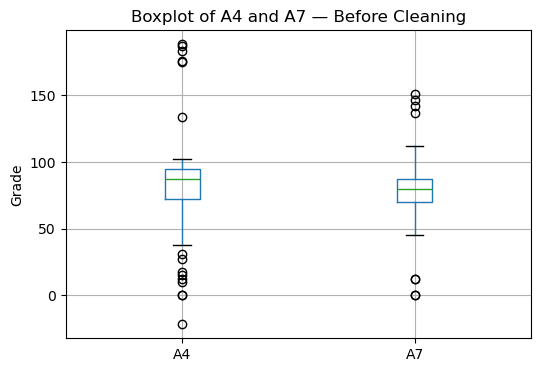

In [ ]:
import matplotlib.pyplot as plt

# Boxplot to visually identify outliers in A4 and A7 before cleaning
df[['A4', 'A7']].boxplot(figsize=(6,4))
plt.title("Boxplot of A4 and A7 — Before Cleaning")
plt.ylabel("Grade")
plt.show()

In [ ]:
# So look at the A4 outliers we see that it has a max possible score of 105 (100 _ 5) bonus points that tells me that any of the values outsides this range is a sus
# U068: negative grade is impossible in the grading system. -> data entry error?!
# U007, U025, U031, U037, U083: way to exceed the max 105. -> data entry error?!
# U004, U005: zero is technically possible so it is okey for now

# In the A7 outliers. The max possible score is 100 since there is no bonus points -> any value more than 100 is a sus
# U015, U051, U069, U083. way to exceed the max 100. -> data entry error?!
# U004, U085: zero is technically possible so it is okey for now
# U010, U055: low but still possible so it is okey for now

In [ ]:
# define the valid max for A4 and A7
a4_max = 105
a7_max = 100 

# option 1. Remove rows with invalid outliers
outlier_ids_a4 = a4_outliers[a4_outliers['A4'] > a4_max | (a4_outliers['A4'] < 0)]['user_id']
outlier_ids_a7 = a7_outliers[a7_outliers['A7'] > a7_max | (a7_outliers['A7'] < 0)]['user_id']
all_outlier_ids = set(outlier_ids_a4) | set(outlier_ids_a7)

df_out_option1 = df_option3[~df_option3['user_id'].isin(all_outlier_ids)].copy()
print(f"Original size: {len(df_option3)}")
print(f"After removing outliers: {len(df_out_option1)}")
print(f"Rows removed: {len(df_option3) - len(df_out_option1)}")

Original size: 86
After removing outliers: 76
Rows removed: 10


In [ ]:
# option 2. Replace invalid outliers with mean
df_out_option2 = df_option3.copy()

# calculate mean excluding invalid values for A4
a4_mean = df_out_option2[(df_out_option2['A4'] >= 0) & (df_out_option2['A4'] <= a4_max)]['A4'].mean()
# calculate mean excluding invalid values for A7
a7_mean = df_out_option2[(df_out_option2['A7'] >= 0) & (df_out_option2['A7'] <= a7_max)]['A7'].mean()

# replace invalid A4 values with mean
df_out_option2.loc[(df_out_option2['A4'] > a4_max) | (df_out_option2['A4'] < 0), 'A4'] = round(a4_mean, 1)
# replace invalid A7 values with mean
df_out_option2.loc[(df_out_option2['A7'] > a7_max) | (df_out_option2['A7'] < 0), 'A7'] = round(a7_mean, 1)

print(f"Mean used for A4 replacement: {a4_mean:.2f}")
print(f"Mean used for A7 replacement: {a7_mean:.2f}")
print(f"Dataset size: {len(df_out_option2)}")

Mean used for A4 replacement: 77.29
Mean used for A7 replacement: 73.78
Dataset size: 86


In [ ]:
# option 3. Replace invalid outliers with median
df_out_option3 = df_option3.copy()

# calculate median excluding invalid values for A4
a4_median = df_out_option3[(df_out_option3['A4'] >= 0) & (df_out_option3['A4'] <= a4_max)]['A4'].median()
# calculate median excluding invalid values for A7
a7_median = df_out_option3[(df_out_option3['A7'] >= 0) & (df_out_option3['A7'] <= a7_max)]['A7'].median()

# replace invalid A4 values with median
df_out_option3.loc[(df_out_option3['A4'] > a4_max) | (df_out_option3['A4'] < 0), 'A4'] = round(a4_median, 1)
# replace invalid A7 values with median
df_out_option3.loc[(df_out_option3['A7'] > a7_max) | (df_out_option3['A7'] < 0), 'A7'] = round(a7_median, 1)

print(f"Median used for A4 replacement: {a4_median:.2f}")
print(f"Median used for A7 replacement: {a7_median:.2f}")
print(f"Dataset size: {len(df_out_option3)}")

Median used for A4 replacement: 87.50
Median used for A7 replacement: 80.00
Dataset size: 86


In [ ]:
# compare the 3 options
print("option 1. Remove outliers:")
print(df_out_option1[['A4', 'A7']].describe().round(2))

print("\noption 2. Replace with Mean:")
print(df_out_option2[['A4', 'A7']].describe().round(2))

print("\noption 3. Replace with Median:")
print(df_out_option3[['A4', 'A7']].describe().round(2))

option 1. Remove outliers:
           A4      A7
count   76.00   76.00
mean    75.90   76.44
std     29.05   18.59
min    -21.60    0.00
25%     71.20   72.35
50%     87.50   80.00
75%     93.65   85.15
max    133.80  112.30

option 2. Replace with Mean:
           A4     A7
count   86.00  86.00
mean    77.29  73.78
std     24.58  18.83
min      0.00   0.00
25%     76.47  72.50
50%     87.50  78.80
75%     92.18  83.80
max    102.50  98.80

option 3. Replace with Median:
           A4     A7
count   86.00  86.00
mean    78.12  74.29
std     24.74  18.91
min      0.00   0.00
25%     76.85  72.50
50%     87.50  80.00
75%     92.18  83.80
max    102.50  98.80


In [ ]:
# Rationale is same as before. Option 1 is too risky cause it remove 10 students. Option 2 is not bad but mean is sightky sensitive to remaining extreme values. so we go with option 3. 
# It retains all 86 students, all values are now within valid range, the median replacement value is more rebust to extreme values than the mean. 
# So in conclusion, after cleaning, the dataset is free of impossible values and missing entries in two most important columns A4 and A7. 
# The median imputation strategy was consistently the best choice across both misisng value handling and outlier cause it preserves the full data set and being resistant to the influence of extreme values

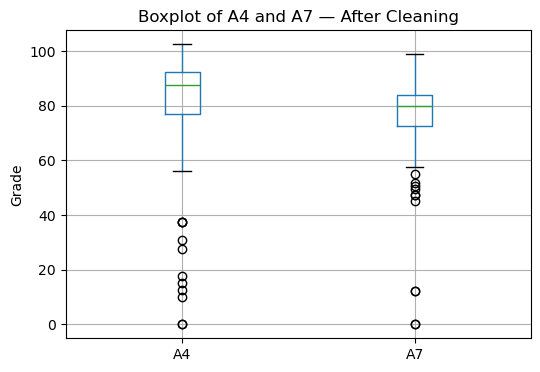

In [ ]:
# Boxplot for A4 and A7 after cleaning
df_out_option3[['A4', 'A7']].boxplot(figsize=(6,4))
plt.title("Boxplot of A4 and A7 — After Cleaning")
plt.ylabel("Grade")
plt.show()